# Random generation of factorized expression trees

## Abstract

This experiment constructs reproducible random abstract syntax trees for discrete-time mechanisms. The sampled AST stores only the functional structure and named slots. Continuous coefficients and discrete lag values are sampled afterward and retained in separate bindings. For a fixed number of binary operators, tree shapes are sampled through Catalan-weighted recursive splits, while commutative operators receive a deterministic child order. The resulting representation supports independent evaluation of structure recovery, lag recovery, and coefficient estimation, and it prepares each indexed sample for future parallel generation.

The design follows the synthetic-expression pipeline used by [D'Ascoli et al., *Deep Symbolic Regression for Recurrent Sequences* (2022)](https://proceedings.mlr.press/v162/d-ascoli22a.html): sample a tree, assign operators and terminals, bind values, and execute the resulting recurrence. Here the representation explicitly separates the mechanism skeleton from numerical coefficient and lag bindings.

## 1. Representation used in this experiment

A sampled mechanism is divided into three objects:

1. **AST skeleton:** `ADD`, `MULTIPLY`, `TIME`, `PARAMETER(Pi)`, and `LAG(xj, Li)`;
2. **continuous binding:** values assigned to `P0, P1, ...`;
3. **discrete binding:** integer lags assigned to `L0, L1, ...`.

For example, the skeleton `P0 * LAG(0, L0) + P1 * t` becomes a complete equation only after values such as `P0=0.7`, `L0=3`, and `P1=0.02` are bound.

In [1]:
from collections import Counter
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parents[1]
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.generators import (
    RandomTreeConfig,
    derive_sample_seed,
    full_binary_tree_shape_count,
    sample_random_mechanism,
    sample_random_mechanisms,
)
from tsfmxai.representations import (
    Add,
    Lag,
    Parameter,
    canonicalize_and_relabel,
    children,
    lag_slots,
    leaf_count,
    node_count,
    node_label,
    operator_count,
    parameter_slots,
    to_skeleton_formula,
    tree_depth,
)

ROOT_SEED = 20260929
CONFIG = RandomTreeConfig(
    minimum_operators=1,
    maximum_operators=6,
    num_series=2,
    minimum_lag=1,
    maximum_lag=12,
    parameter_probability=0.40,
    time_probability=0.15,
    lag_probability=0.45,
    add_probability=0.65,
    require_lag=True,
)
print(f"Project root: {PROJECT_ROOT}")
print(f"Root seed: {ROOT_SEED}")
print(CONFIG)

Project root: C:\Users\mateu\repos\tsfmxai
Root seed: 20260929
RandomTreeConfig(minimum_operators=1, maximum_operators=6, num_series=2, minimum_lag=1, maximum_lag=12, parameter_probability=0.4, time_probability=0.15, lag_probability=0.45, add_probability=0.65, minimum_parameter_magnitude=0.05, maximum_parameter_magnitude=0.9, require_lag=True, require_time=False)


**What the cell did.** It loaded the reusable sampler from `src/tsfmxai`, fixed the root seed, and declared the complete grammar and sampling ranges. The notebook therefore records every choice required to reproduce the candidates.

## 2. Sampling the binary topology

A full binary tree with $n$ operator nodes has $n+1$ leaves. The number of distinct ordered shapes is the Catalan number

$$C_n = \frac{1}{n+1}\binom{2n}{n}.$$

At a node containing $n$ operators, the sampler assigns $k$ operators to the left subtree with probability proportional to $C_k C_{n-1-k}$. Consequently, every ordered full-binary shape has the same probability for fixed $n$.

### Pseudocode of the implemented sampler

The implementation is in [`src/tsfmxai/generators/random_expression.py`](../../src/tsfmxai/generators/random_expression.py). The public entry points are `sample_random_mechanism()` for one tree and `sample_random_mechanisms()` for an indexed batch. The recursive topology sampler is `_sample_full_binary_tree()`. Canonical node definitions and commutative ordering are implemented in [`src/tsfmxai/representations/expression.py`](../../src/tsfmxai/representations/expression.py).

```text
ALGORITHM SAMPLE_INDEXED_MECHANISM(config, root_seed, sample_index)
    sample_seed <- DERIVE_SEED(root_seed, sample_index)
    rng         <- RANDOM_GENERATOR(sample_seed)

    n_operators <- UNIFORM_INTEGER(
                       config.minimum_operators,
                       config.maximum_operators
                   )
    n_leaves    <- n_operators + 1

    terminal_kinds <- CATEGORICAL_SAMPLE(
                          {PARAMETER, TIME, LAG},
                          config.terminal_probabilities,
                          n_leaves
                      )
    ENFORCE_REQUIRED_TERMINALS(terminal_kinds, config)
    terminals <- CREATE_PLACEHOLDER_TERMINALS(terminal_kinds, rng)

    raw_tree <- SAMPLE_SUBTREE(n_operators, terminals, rng, config)
    tree     <- ORDER_COMMUTATIVE_CHILDREN(raw_tree)
    tree     <- RELABEL_SLOTS_IN_PREORDER(tree, P0..., L0...)

    parameter_values <- SAMPLE_CONTINUOUS_VALUES(tree.parameter_slots, rng)
    lag_values       <- SAMPLE_INTEGER_LAGS(tree.lag_slots, rng)

    RETURN (tree, parameter_values, lag_values, sample_seed, sample_index)


ALGORITHM SAMPLE_SUBTREE(n_operators, terminals, rng, config)
    IF n_operators = 0 THEN
        RETURN terminals[0]
    END IF

    FOR k IN {0, ..., n_operators - 1} DO
        split_weight[k] <- CATALAN(k) * CATALAN(n_operators - 1 - k)
    END FOR

    left_operators  <- CATEGORICAL_SAMPLE(split_weight)
    right_operators <- n_operators - 1 - left_operators
    left_leaf_count <- left_operators + 1

    left  <- SAMPLE_SUBTREE(
                 left_operators,
                 terminals[0 : left_leaf_count],
                 rng, config
             )
    right <- SAMPLE_SUBTREE(
                 right_operators,
                 terminals[left_leaf_count :],
                 rng, config
             )

    operator <- ADD with probability config.add_probability
                otherwise MULTIPLY
    RETURN operator(left, right)
```

The first algorithm separates topology, lag slots, and coefficient values. The recursive algorithm explains precisely how Catalan weights choose the number of operators assigned to each subtree.

In [2]:
catalan_counts = {
    operator_nodes: full_binary_tree_shape_count(operator_nodes)
    for operator_nodes in range(7)
}
print("Number of full-binary shapes:")
for operator_nodes, shape_count in catalan_counts.items():
    print(f"  {operator_nodes} operators -> {shape_count} shapes")

Number of full-binary shapes:
  0 operators -> 1 shapes
  1 operators -> 1 shapes
  2 operators -> 2 shapes
  3 operators -> 5 shapes
  4 operators -> 14 shapes
  5 operators -> 42 shapes
  6 operators -> 132 shapes


**What the cell did.** It calculated the exact number of possible full-binary shapes for zero through six operators. The rapid Catalan growth shows why predicting or searching unrestricted trees quickly becomes difficult.

## 3. Generate candidate mechanisms

Each sample receives a seed derived from `(ROOT_SEED, sample_index)`. This gives the same mechanism to an index even when indices are later distributed across CPU workers in a different order.

In [3]:
examples = sample_random_mechanisms(CONFIG, root_seed=ROOT_SEED, count=8)
example = examples[1]

print(f"Selected sample index: {example.sample_index}")
print(f"Derived sample seed: {example.seed}")
print(f"Generated {len(examples)} example mechanisms.")

Selected sample index: 1
Derived sample seed: 10885231728690395407
Generated 8 example mechanisms.


**What the cell did.** It generated eight independently seeded mechanisms and selected sample 1 for inspection. Reconstructing this index requires only the configuration, root seed, and index.

In [4]:
print("Canonical AST:")
print(example.tree)
print("\nSkeleton formula:")
print(example.skeleton_formula)
print("\nContinuous parameter binding:")
print(dict(example.binding.parameter_values))
print("\nDiscrete lag binding:")
print(dict(example.binding.lag_values))
print("\nFully bound mathematical formula:")
print(f"x_0(t) = {example.formula}")

Canonical AST:
ADD
    ├── ADD
    │   ├── LAG(x0, L0)
    │   └── MULTIPLY
    │       ├── LAG(x1, L1)
    │       └── PARAMETER(P0)
    └── MULTIPLY
        ├── PARAMETER(P1)
        └── TIME

Skeleton formula:
((LAG(0, L0) + (LAG(1, L1) * P0)) + (P1 * t))

Continuous parameter binding:
{'P0': 0.4457106815618323, 'P1': 0.10841154187786492}

Discrete lag binding:
{'L0': 11, 'L1': 5}

Fully bound mathematical formula:
x_0(t) = ((x_0(t-11) + (x_1(t-5) * 0.445711)) + (0.108412 * t))


**What the cell did.** It displayed the same mechanism at four levels. The tree and skeleton describe the relationship; the two binding dictionaries contain the continuous coefficients and discrete lags; the final line combines them only for human-readable presentation.

In [5]:
binary_operators = operator_count(example.expression)
leaves = leaf_count(example.expression)
nodes = node_count(example.expression)

assert leaves == binary_operators + 1
assert nodes == 2 * binary_operators + 1
assert set(parameter_slots(example.expression)) == set(example.binding.parameter_values)
assert set(lag_slots(example.expression)) == set(example.binding.lag_values)

print(f"Binary operators: {binary_operators}")
print(f"Leaves: {leaves}")
print(f"Total nodes: {nodes}")
print("Full-binary and binding invariants: passed")

Binary operators: 4
Leaves: 5
Total nodes: 9
Full-binary and binding invariants: passed


**What the cell did.** It verified the mathematical identities of a full binary tree and checked that every placeholder in the AST has exactly one corresponding value in the external bindings.

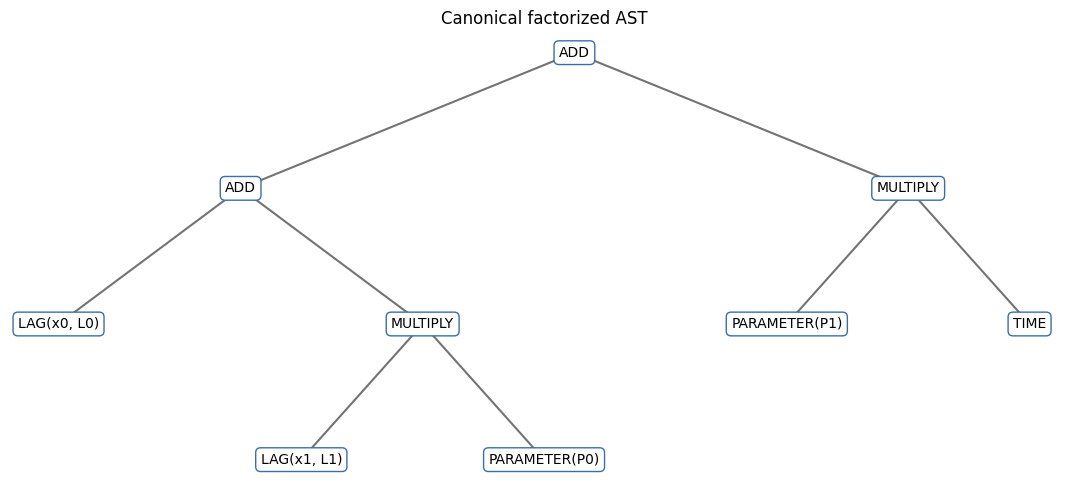

In [6]:
def plot_expression_tree(expression, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 5))

    positions = {}
    labels = {}
    edges = []
    next_leaf_x = 0

    def visit(node, depth):
        nonlocal next_leaf_x
        node_id = id(node)
        direct_children = children(node)
        child_x = []
        for child in direct_children:
            child_id, x_position = visit(child, depth + 1)
            edges.append((node_id, child_id))
            child_x.append(x_position)
        if child_x:
            x_position = float(np.mean(child_x))
        else:
            x_position = float(next_leaf_x)
            next_leaf_x += 1
        positions[node_id] = (x_position, -depth)
        labels[node_id] = node_label(node)
        return node_id, x_position

    visit(expression, 0)
    for parent, child in edges:
        x_parent, y_parent = positions[parent]
        x_child, y_child = positions[child]
        ax.plot([x_parent, x_child], [y_parent, y_child], color="0.45", zorder=1)
    for node_id, (x_position, y_position) in positions.items():
        ax.text(
            x_position,
            y_position,
            labels[node_id],
            ha="center",
            va="center",
            bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#3b6ea8"},
            zorder=2,
        )
    ax.set_title("Canonical factorized AST")
    ax.axis("off")
    return ax

figure, axis = plt.subplots(figsize=(11, 5))
plot_expression_tree(example.expression, axis)
figure.tight_layout()
plt.show()

**What the cell did.** It rendered the canonical structure. `PARAMETER(Pi)` and `LAG(xj, Li)` remain placeholders in the diagram, making the separation between relational structure and bound numbers visually explicit.

## 4. Inspect a larger sampled corpus

The next cell samples 1,000 candidates to check whether the configured operator-count range, lag requirement, and structural diversity appear in practice. These are candidate formulas; stability and semantic usefulness are assessed by the later compilation and trajectory-screening stage.

Candidates: 1000
Unique canonical skeletons: 741
Mean tree depth: 4.064
Mean lag slots: 2.177
Mean parameter slots: 1.723


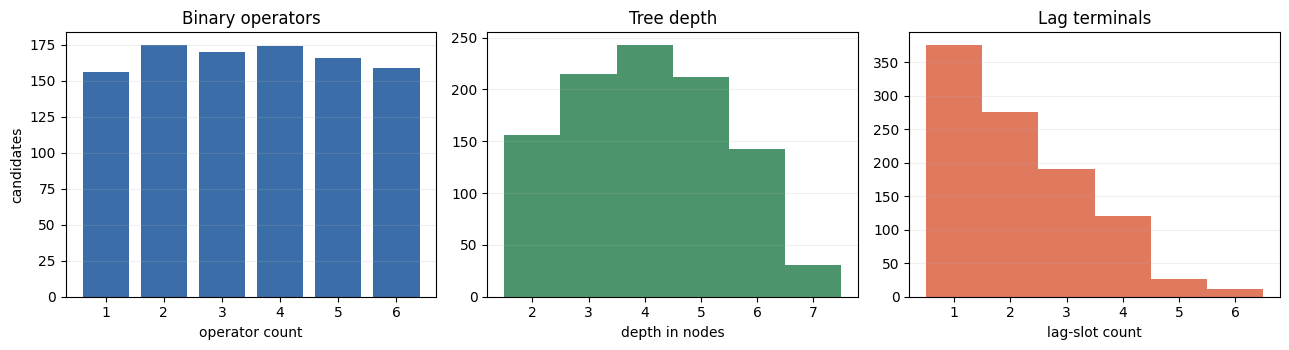

In [7]:
corpus = sample_random_mechanisms(CONFIG, root_seed=ROOT_SEED, count=1000)
operator_counts = [operator_count(item.expression) for item in corpus]
depths = [tree_depth(item.expression) for item in corpus]
lag_counts = [len(lag_slots(item.expression)) for item in corpus]
parameter_counts = [len(parameter_slots(item.expression)) for item in corpus]
unique_skeletons = len({item.skeleton_formula for item in corpus})

print(f"Candidates: {len(corpus)}")
print(f"Unique canonical skeletons: {unique_skeletons}")
print(f"Mean tree depth: {np.mean(depths):.3f}")
print(f"Mean lag slots: {np.mean(lag_counts):.3f}")
print(f"Mean parameter slots: {np.mean(parameter_counts):.3f}")

figure, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].bar(*zip(*sorted(Counter(operator_counts).items())), color="#3b6ea8")
axes[0].set(title="Binary operators", xlabel="operator count", ylabel="candidates")
axes[1].hist(depths, bins=np.arange(min(depths) - 0.5, max(depths) + 1.5), color="#4c956c")
axes[1].set(title="Tree depth", xlabel="depth in nodes")
axes[2].hist(lag_counts, bins=np.arange(min(lag_counts) - 0.5, max(lag_counts) + 1.5), color="#e07a5f")
axes[2].set(title="Lag terminals", xlabel="lag-slot count")
for ax in axes:
    ax.grid(axis="y", alpha=0.2)
figure.tight_layout()
plt.show()

**What the cell did.** It summarized structural diversity rather than trajectory behavior. The approximately uniform operator-count bars reflect the configured uniform draw from one to six operators; tree depth and lag count then emerge from topology and terminal sampling.

## 5. Reproducibility under future parallel generation

A mutable random-number stream makes samples depend on worker scheduling. The indexed seed derivation used here gives every sample its own deterministic random stream.

In [8]:
forward = sample_random_mechanisms(CONFIG, root_seed=ROOT_SEED, count=20)
reverse = [
    sample_random_mechanism(
        CONFIG,
        seed=derive_sample_seed(ROOT_SEED, index),
        sample_index=index,
    )
    for index in reversed(range(20))
]

same_seed_reproducibility = forward == sample_random_mechanisms(
    CONFIG, root_seed=ROOT_SEED, count=20
)
index_order_independence = forward == list(reversed(reverse))

assert same_seed_reproducibility
assert index_order_independence
print(f"Same root seed reproduces the batch: {same_seed_reproducibility}")
print(f"Reversing generation order preserves indexed samples: {index_order_independence}")

Same root seed reproduces the batch: True
Reversing generation order preserves indexed samples: True


**What the cell did.** It regenerated the same mechanisms in forward and reverse index order. Both comparisons passed, establishing the seed behavior required before distributing future generation across workers.

## 6. First treatment of equivalent trees

Addition and multiplication are commutative. Therefore, swapping their children should preserve the canonical skeleton. The implementation recursively sorts their children and assigns slot names only afterward.

In [9]:
first_order = Add(Parameter("temporary_a"), Lag(0, "temporary_tau"))
swapped_order = Add(Lag(0, "another_tau"), Parameter("temporary_b"))

canonical_first = canonicalize_and_relabel(first_order)
canonical_swapped = canonicalize_and_relabel(swapped_order)
commutative_example_passed = canonical_first == canonical_swapped

print(to_skeleton_formula(canonical_first))
print(to_skeleton_formula(canonical_swapped))
print(f"Canonical structures are equal: {commutative_example_passed}")
assert commutative_example_passed

(LAG(0, L0) + P0)
(LAG(0, L0) + P0)
Canonical structures are equal: True


**What the cell did.** It constructed two syntactically swapped additions and showed that both become the same canonical AST. This covers commutative permutations; later simplification can extend equivalence handling to associativity, distributivity, and constant folding.

In [10]:
full_binary_invariant = all(
    leaf_count(item.expression) == operator_count(item.expression) + 1
    and node_count(item.expression) == 2 * operator_count(item.expression) + 1
    for item in corpus
)
all_samples_contain_lag = all(lag_slots(item.expression) for item in corpus)

metrics = {
    "sample_count": len(corpus),
    "unique_skeleton_count": unique_skeletons,
    "unique_skeleton_fraction": unique_skeletons / len(corpus),
    "mean_tree_depth_nodes": float(np.mean(depths)),
    "maximum_tree_depth_nodes": max(depths),
    "mean_lag_slots": float(np.mean(lag_counts)),
    "mean_parameter_slots": float(np.mean(parameter_counts)),
    "all_samples_contain_lag": bool(all_samples_contain_lag),
    "full_binary_invariant_passed": bool(full_binary_invariant),
    "same_seed_reproducibility_passed": bool(same_seed_reproducibility),
    "index_order_independence_passed": bool(index_order_independence),
    "commutative_canonicalization_example_passed": bool(commutative_example_passed),
}

assert all_samples_contain_lag
assert full_binary_invariant
print(json.dumps(metrics, indent=2))

{
  "sample_count": 1000,
  "unique_skeleton_count": 741,
  "unique_skeleton_fraction": 0.741,
  "mean_tree_depth_nodes": 4.064,
  "maximum_tree_depth_nodes": 7,
  "mean_lag_slots": 2.177,
  "mean_parameter_slots": 1.723,
  "all_samples_contain_lag": true,
  "full_binary_invariant_passed": true,
  "same_seed_reproducibility_passed": true,
  "index_order_independence_passed": true,
  "commutative_canonicalization_example_passed": true
}


**What the cell did.** It consolidated the experiment's acceptance checks and descriptive results. The generated candidates are ready for the next pipeline stage: bind them to an executable recurrence, sample initial conditions, simulate trajectories, and reject unstable or semantically redundant mechanisms.

In [11]:
from dataclasses import asdict

experiment_record = {
    "experiment_id": "abstract_syntax_tree_random_002",
    "status": "executed",
    "research_question": (
        "Can random symbolic mechanisms be generated reproducibly while keeping "
        "functional structure, continuous coefficients, and discrete lags separate?"
    ),
    "hypothesis": (
        "A Catalan-weighted binary AST can retain the mechanism skeleton while named "
        "parameter and lag slots preserve separate numerical bindings."
    ),
    "configuration": {
        "root_seed": ROOT_SEED,
        "sample_count": len(corpus),
        "example_count": len(examples),
        "tree_sampler": asdict(CONFIG),
        "shape_sampler": "uniform full-binary shape via Catalan splits",
        "canonicalization": (
            "commutative child ordering followed by preorder slot relabeling"
        ),
    },
    "provenance": {
        "execution_date": "2026-09-29",
        "python": sys.version.split()[0],
        "backend": "nbclient",
        "hardware": "CPU",
        "seed_usage": (
            "Each sample seed is derived from (root_seed, sample_index), preserving "
            "sample identity under reordered or parallel generation."
        ),
        "implementation": [
            "src/tsfmxai/representations/expression.py",
            "src/tsfmxai/generators/random_expression.py",
        ],
    },
    "metrics": metrics,
    "scientific_summary": (
        f"The sampler produced {len(corpus)} candidates and {unique_skeletons} distinct "
        "canonical skeletons while preserving binary-tree, lag, reproducibility, and "
        "index-order invariants."
    ),
    "reproduction_command": (
        ".venv\\Scripts\\python.exe -c \"from pathlib import Path; import nbformat; "
        "from nbclient import NotebookClient; p=Path(r'experiments/abstract_syntax_tree/"
        "2_random_tree_generation.ipynb'); "
        "n=nbformat.read(p, as_version=4); NotebookClient(n, timeout=180, "
        "kernel_name='python3').execute(cwd=str(p.parent)); nbformat.write(n, p)\""
    ),
}
print(json.dumps(experiment_record, indent=2))

{
  "experiment_id": "abstract_syntax_tree_random_002",
  "status": "executed",
  "research_question": "Can random symbolic mechanisms be generated reproducibly while keeping functional structure, continuous coefficients, and discrete lags separate?",
  "hypothesis": "A Catalan-weighted binary AST can retain the mechanism skeleton while named parameter and lag slots preserve separate numerical bindings.",
  "configuration": {
    "root_seed": 20260929,
    "sample_count": 1000,
    "example_count": 8,
    "tree_sampler": {
      "minimum_operators": 1,
      "maximum_operators": 6,
      "num_series": 2,
      "minimum_lag": 1,
      "maximum_lag": 12,
      "parameter_probability": 0.4,
      "time_probability": 0.15,
      "lag_probability": 0.45,
      "add_probability": 0.65,
      "minimum_parameter_magnitude": 0.05,
      "maximum_parameter_magnitude": 0.9,
      "require_lag": true,
      "require_time": false
    },
    "shape_sampler": "uniform full-binary shape via Catalan sp

**What the cell did.** It placed the complete experiment record inside the executed notebook: question, hypothesis, configuration, provenance, seed behavior, metrics, scientific conclusion, implementation paths, and exact reproduction command.